# Support Vector Classification (SVC) - Beginner Friendly Walkthrough

##  1. Import Required Libraries

In [4]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Create a synthetic dataset

In [7]:
# Create a synthetic dataset
X, y = make_classification(n_samples=200,   # 200 points
                            n_features=2,    # 2 features for easy visualization
                            n_informative=2, # Both features are informative
                            n_redundant=0,   # No redundant features
                            n_clusters_per_class=1,
                            flip_y=0.1,       # Add some noise
                            random_state=42)

# Convert to a pandas DataFrame
data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
data['Target'] = y

data.head()

,Feature1,Feature2,Target
0,0.622201,-3.121909,0
1,1.555968,2.971449,1
2,1.126547,-0.208767,0
3,1.738265,1.857568,1
4,0.510960,1.877681,1


## 3. Visualize the Dataset

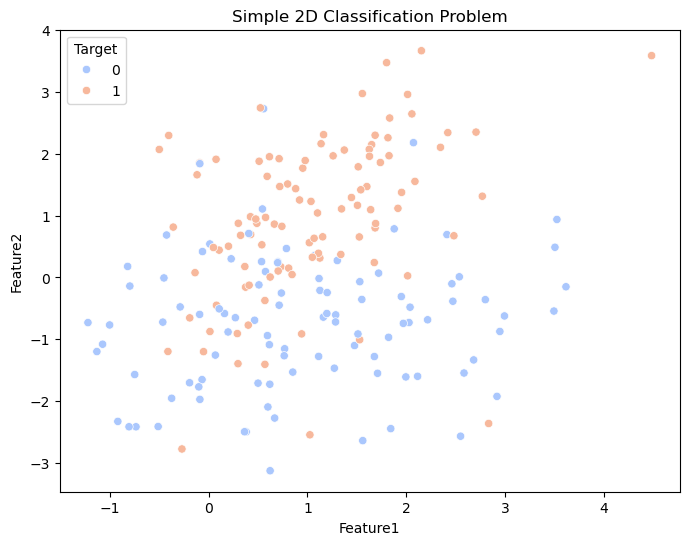

In [10]:
# Plot the data
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='Feature1', y='Feature2', hue='Target', palette='coolwarm')
plt.title('Simple 2D Classification Problem')
plt.show()

## Split the Data

In [13]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 140
Testing samples: 60


## 5. Build the SVC Model

In [16]:
# Create the SVC model
model = SVC(kernel='linear', C=1.0)

# Train the model
model.fit(X_train, y_train)

SVC(kernel='linear')

## 6. Make Predictions

In [19]:
# Predict on test data
y_pred = model.predict(X_test)

## 7. Evaluate the Model

### Accuracy

In [23]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.80


### Confusion Matrix

In [26]:
cm = confusion_matrix(y_test, y_pred)

### Plot Confusion Matrix

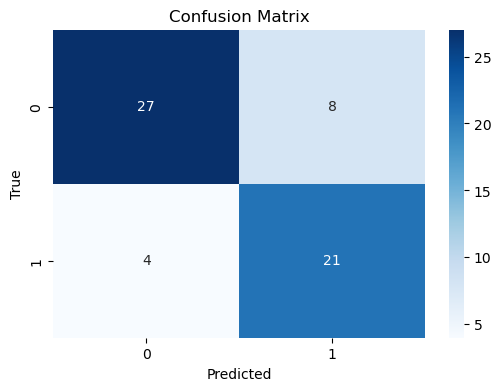

In [29]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Classification Report

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82        35
           1       0.72      0.84      0.78        25

    accuracy                           0.80        60
   macro avg       0.80      0.81      0.80        60
weighted avg       0.81      0.80      0.80        60



## 8. Visualize the Decision Boundary

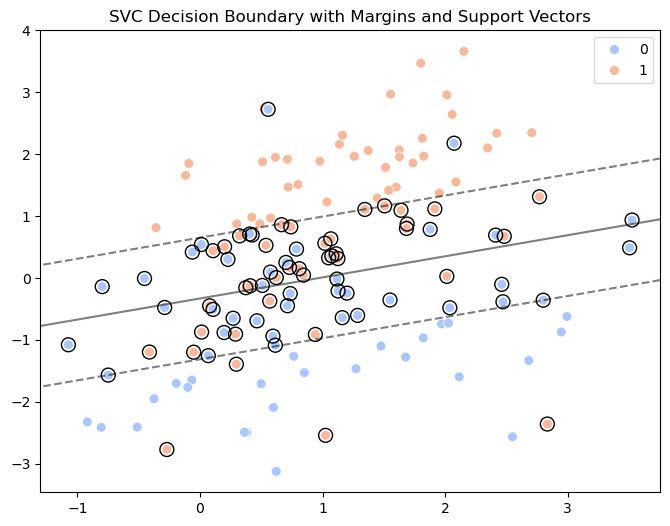

In [35]:
# Plot the decision boundary
plt.figure(figsize=(8,6))

# Plot all points
sns.scatterplot(x=X_train[:,0], y=X_train[:,1], hue=y_train, palette='coolwarm', s=50)

# Create meshgrid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--','-','--'])

# Highlight support vectors
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k')

plt.title('SVC Decision Boundary with Margins and Support Vectors')
plt.show()

 9. Summary of What We Learned
SVC tries to create the best hyperplane (line) to separate classes.

Support Vectors are the important points near the margin.

Margin is the area between the two dashed lines (ideally wide).

C parameter controls strictness:
➔ Large C = hard margin, fewer mistakes allowed.
➔ Small C = soft margin, more mistakes allowed for better generalization.

Linear kernel is enough when the data is linearly separable.


---

✅ **This notebook builds:**  
- Your **intuition** about SVMs, hyperplanes, margins, and support vectors.  
- Your **confidence** in using `scikit-learn`, `numpy`, `pandas`, `matplotlib`, and `seaborn` together.

---

